<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/Relativistic_Synchrotron_Radiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<b>Nombre</b>: Diego Gutiérrez R
<br>
<b>Objetivo:</b> Simular y estudiar como funciona la radiación sincrotrón según la teoria especial de la relatividad.

## Enunciado

<center>
<img src="https://www.southampton.ac.uk/~pg3e14/v404/BHJetRobertHurt.jpeg" width=100%>
</center>

Los jets astrofísicos son colosales chorros de plasma expulsados desde las cercanías de objetos compactos como agujeros negros supermasivos. Las partículas dentro de estos jets, principalmente electrones y protones, alcanzan velocidades muy cercanas a la de la luz, lo que los convierte en laboratorios cósmicos perfectos para estudiar la cinemática y dinámica relativista.

Considera un jet que se propaga a lo largo del eje $z$. Un modelo simplificado pero poderoso para el campo magnético dentro del jet es un campo helicoidal:

$$
B=B_z \tilde{e_z}+B_\phi(r) \tilde{e_\phi}
$$
compuesto por una componente a lo largo del jet $B_z\equiv B_0$ (también llamada *componente poloidal*) y una componente azimutal $B_\phi=B_1/r$ que disminuye con la distancia al eje (también llamada *componente toroidal*).

Vamos a modelar el movimiento de electrones dentro del jet y la radiación que ellos producen al acelerarse en el campo magnético (*radiación sincrotrón*).

Para ello te sugiero los siguientes lineamientos:

1. **Simulación de las trayectorias**. Usando el tensor de Faraday (escribelo explícitamente para el campo descrito) y la forma covariante de la cuadrifuerza de Lorentz, escribe las ecuación de movimiento de los electrones y resuélvelas numéricamente para trazar sus trayectorias en el espacio de tres dimensiones.  Puedes usar como condiciones iniciales para la posición del electrón una posición $(x_0, y_0, z_0) = (R_0, 0, 0)$ donde $R_0$ es un radio inicial pequeño (escogelo), y $\vec v_0 = (0, 0, v_{0z})$.

   > **Sugerencias numéricas**: La componente poloidal de campos magnéticos medidos en los discos de acreción es del orden de unos cuantos gauss, G. Por otro lado el valor de $B_1$ de la componente toroidal tiene ordenes de magnitud 10 veces menor (unas décimas de G$\cdot$m). Para el radio inicial se pueden usar valores del orden de 1 metro. Electrones de baja energía cerca del punto de emisión, que son los que usaremos en esta simulación, pueden tener $\gamma = 2-50$. En jets reales fenómenos de aceleración pueden producir $\gamma\gg 10^3$ pero esto no es práctico para la simulación.

2. **Cinemática y electrodinámica relativista**. Usando la solución numérica, pon a prueba algunos de los resultados teóricos obtenidos en el curso. Por ejemplo, en cada punto de la trayectoria verifica numéricamente que $U^\mu A_\mu = 0$. Grafica el tiempo propio del electrón como función del tiempo coordenado ¿qué observas?. Grafica el módulo de la cuadrivelocidad como función del tiempo propio ¿qué observas?. Toma un punto en la trayectoria del electrón y calcula la matriz de transformación de Lorentz-Einsteins con la velocidad instantánea que tiene el electrón en ese punto. Usando esa matriz, determina las componentes del tensor de Lorentz observadas en el sistema de referencia del electrón. ¿Qué observas?.

3. **Radiación sincrotrón**. Todos los Jets astrofísicos emiten radiación electromagnética por la presencia de electrones acelerados (cargas aceleradas emiten radiación electromagnética). Sin contar con los efectos del beaming relativista, la frecuencia de la radiación debería ser igual a la frecuencia con la que "gira" el electrón en el campo. Estima a partir de las trayectorias obtenidas esta frecuencia de "giro", $f_g$ y compárala con el valor esperado teóricamente, $f_g = e|B|/(2\pi\gamma m_e)$.  Por efecto del beaming relativista, sin embargo, la radiación observada es muy diferente: tiene un espectro continuo muy asimétrico en el que la mitad de la energía de la radiación se emite por encima de la denominada frecuencia crítica:

   $$
   f_\mathrm{crit}=\frac{3}{4 \pi} \gamma^2 \frac{e B_{\perp}}{m_e}
   $$
   donde $B_{\perp}$ es la componente del campo perpendicular a la velocidad del electrón. A esta radiación se la llama, *radiación sincrotrón*. El pico de la radiación emitida por el electrón en realidad ocurre a una frecuencia $f_\mathrm{peak}\approx 0.29 f_\mathrm{crit}$. Calcula la variación en la frecuencia a lo largo de la trayectoria del electrón.

4. **Beaming relativista en el jet**. Aunque la radiación emitida por un electrón acelerado en un campo magnético no es isotrópica, vamos a suponer que en el sistema de referencia del electrón lo es. Si ese es el caso vamos a ver cómo es la luz percibida por un observador lejano. Ubica un observador mirando hacia el origen en un ángulo $\theta_\mathrm{obs}$ con respecto al eje z (puedes ubicarlo sobre el plano x-y o y-z). Por efecto del beaming relativista, el observador solo percibe luz cuando el ángulo entre su velocidad y la dirección en la que mira es menor a $\theta_\mathrm{beam}$. Haz un gráfico de intensidad de la luz como función del tiempo coordenado. Varía la posición del observador respecto del jet y estudia cómo cambia el patrón de la intensidad de la luz.



## Solución

# Punto 1:
##*Trayectoria del electrón*

*El tensor de Faraday $F^{\mu\nu}$ se puede escribir de forma matricial como:*


<br>

$$
F^{\mu\nu} =
\begin{pmatrix}
0 & -E_x/c & -E_y/c & -E_z/c \\[6pt]
E_x/c & 0 & -B_z & B_y \\[6pt]
E_y/c & B_z & 0 & -B_x \\[6pt]
E_z/c & -B_y & B_x & 0
\end{pmatrix}
$$

<br>

*Ahora como las componentes del campo eléctrico son cero, se puede reescribir de la sigueinte manera:*

<br>

$$
F^{\mu\nu} =
\begin{pmatrix}
0 & 0 & 0 & 0 \\[6pt]
0 & 0 & -B_z & B_y \\[6pt]
0 & B_z & 0 & -B_x \\[6pt]
0 & -B_y & B_x & 0
\end{pmatrix}
$$

<br>



*Recordando las relaciones para el cambio de coordenadas*

<br>

$$
r = \sqrt{x^2 + y^2}, \qquad \varphi = arctan(y, x)
$$

<br>

$$
\begin{aligned}
\hat{e}_r(\varphi) &= \cos\varphi\,\hat{e}_x + \sin\varphi\,\hat{e}_y, \\
\hat{e}_\varphi(\varphi) &= -\sin\varphi\,\hat{e}_x + \cos\varphi\,\hat{e}_y, \\
\hat{e}_z &= \hat{e}_z.
\end{aligned}
$$

<br>

$$
\cos\varphi = \frac{x}{r}, \qquad \sin\varphi = \frac{y}{r} \quad (r > 0)
$$


*El campo dado es:*

$$
\mathbf{B} = B_0\,\hat{e}_z + \frac{B_1}{r}\,\hat{e}_\varphi
$$

*Sustituyendo $\hat{e}_\varphi$ por su expresión en la base cartesiana:*

$$
\mathbf{B} = B_0\,\hat{e}_z + \frac{B_1}{r}\big(-\sin\varphi\,\hat{e}_x + \cos\varphi\,\hat{e}_y\big)
$$

<br>

*Resolviendo para $B_x$:*

$$
\begin{aligned}
B_x &= -\frac{B_1}{r}\sin\varphi \\
&= -\frac{B_1}{r}\frac{y}{r} \\
&= -B_1\,\frac{y}{r^2} \\
&= -B_1\,\frac{y}{x^2 + y^2}
\end{aligned}
$$

<br>

*El procedimiento es análogo con $B_y$, por otro lado $B_z$ no cambia al cambiar el sistema de coordenadas por tanto, el tensor de Faraday tiene la forma*

<br>


$$
F^{\mu\nu} =
\begin{pmatrix}
0 & 0 & 0 & 0 \\[6pt]
0 & 0 & -B_0 & B_1\,\frac{x}{x^2 + y^2} \\[6pt]
0 & B_0 & 0 & B_1\,\frac{y}{x^2 + y^2}\\[6pt]
0 & -B_1\,\frac{x}{x^2 + y^2} & - B_1\,\frac{y}{x^2 + y^2}& 0
\end{pmatrix}
$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from scipy.signal import periodogram

In [ ]:
# Constantes del problema
qe = -1.602176634e-19
me = 9.10938356e-31
c  = 299792458.0

# parametros del campo magnético
Bo_G = 4.0        # gauss
B1_G = 0.5

# Pasandolo a Teslas para trabar en el S.I
Bo = Bo_G * 1e-4
B1 = B1_G * 1e-4

*Las ecuaciones de movimiento por la fuerza de Lorentz se recuperaron del texto guía del curso, compartido por el profesor y se aplicará para este caso específico*

<br>

$$
m \frac{d^2 t}{d\tau^2} = \frac{\gamma}{c}  \, \vec{F} \cdot \vec{v}
$$


<br>

$$
m \frac{d^2 \vec{r}}{d\tau^2} = \gamma \, \vec{F}
$$

<br>

*El factor de Lorentz está dado por:*

$$
\gamma = \left(1 - \frac{v^2}{c^2} \right)^{-1/2}.
$$

*La ecuación de movimiento relativista (en forma covariante) es:*

<br>

$$
m \frac{dU^\mu}{d\tau} = q\, F^{\mu}{}_{\nu}\, U^\nu
$$

<br>

$$
A^{\mu} = \frac{q}{m}  F^{\mu}{}_{\nu}\, U^\nu
$$

*donde:*
- $ U^\mu = (\gamma c, \gamma \vec{v}) $ es el **cuadrivelocidad**,
- $ F^{\mu\nu} $ es el **tensor de Faraday**,
- $ \tau $ es el **tiempo propio**,  
- $ q $ y $ m $ son la carga y masa de la partícula.






In [ ]:
def campo_E(r, t):
    return np.array([0.0, 0.0, 0.0])

def campo_B(r, t):
    x, y, z = r
    r2 = x*x + y*y
    denom = r2 + 1e-9
    Bx = -B1 * y / denom
    By =  B1 * x / denom
    Bz =  Bo
    return np.array([Bx, By, Bz])

In [ ]:
def F_tensor(E, B):
    F = np.zeros((4,4))
    # componentes eléctricas (0,i) y (i,0)
    F[0,1:] = E / c        # F^{0i} = E^i / c
    F[1:,0] = -E / c       # F^{i0} = -E^i / c

    # componentes magnéticas (antisimétricas)
    # F^{12} = -Bz, F^{13} = By, F^{23} = -Bx  (índices 1=x,2=y,3=z)
    F[1,2] = -B[2]; F[2,1] = B[2]
    F[1,3] =  B[1]; F[3,1] = -B[1]
    F[2,3] = -B[0]; F[3,2] =  B[0]
    return F

def edm_lorentz(Y, tau, m, q):

    t = Y[0]
    r = Y[1:4]
    U = Y[4:8]

    # campos
    E = campo_E(r, t)
    B = campo_B(r, t)

    # tensor F^{mu nu}
    F_upup = F_tensor(E, B)

    # métrica g_{mu nu}
    eta = np.diag([1.0, -1.0, -1.0, -1.0])

    # Bajando el indice
    F_mixed = F_upup @ eta

    # ecuaciones de movimiento
    dtdtau = U[0] / c
    drdtau = U[1:4]
    dUdtau = (q / m) * (F_mixed @ U)

    return np.concatenate(([dtdtau], drdtau, dUdtau))

*Para la **componente temporal** $ \mu = 0 $, se tiene:*

$$
m \frac{dU^0}{d\tau} = q\, F^{0i} U_i
$$

*y recordando que:*

$$
F^{0i} = \frac{E_i}{c}, \quad \text{y} \quad U_i = \gamma v_i,
$$

*obtenemos:*

$$
\boxed{ \frac{dU^0}{d\tau} = \frac{q}{m} \frac{\gamma}{c} \, \vec{E} \cdot \vec{v} }
$$

<br>

*El cambio en la componente temporal $ U^0 = \gamma c $ depende del **producto escalar** entre la velocidad y el campo eléctrico.*  

*Para este caso el campo eléctrico es nulo $ (\vec{E} = 0) $, entonces:*

$$
\frac{dU^0}{d\tau} = 0,
$$




In [ ]:
# Condiciones iniciales
Ro = 3.5
voz = 0.9 * c
gammao = 1.0 / np.sqrt(1.0 - (voz/c)**2)

# 4-velocidad inicial
U0_ini = gammao * c  # U^0 = γc
Ux_ini = 0.0
Uy_ini = 0.0
Uz_ini = gammao * voz  # U^z = γv_z

to = 0.0
Yos = np.array([to, Ro, 0.0, 0.0, U0_ini, Ux_ini, Uy_ini, Uz_ini])


Yos

array([0.00000000e+00, 3.50000000e+00, 0.00000000e+00, 0.00000000e+00,
       6.87771068e+08, 0.00000000e+00, 0.00000000e+00, 6.18993961e+08])

*Una vez se obtuvieron las ecuaciones de movimiento y las condiciones iniciales se pueden integrar en el tiempo con la finalidad de graficar la trayectoria del electrón acelerado.*

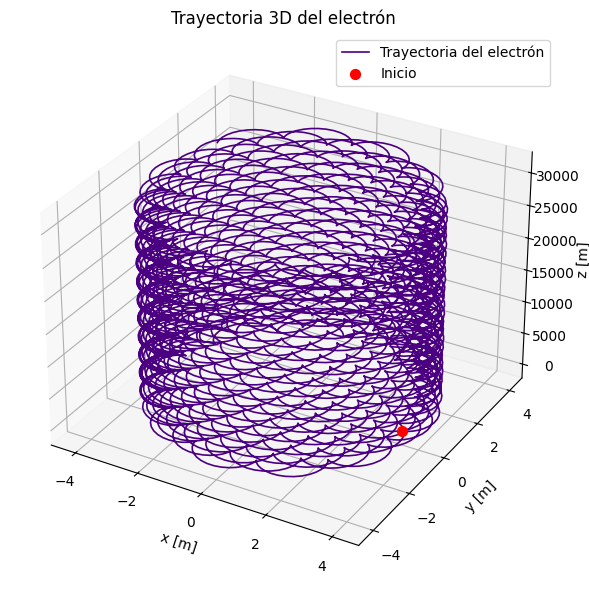

In [ ]:
# Resolviendo la ecuación diferencial
taus = np.linspace(0,5e-5,10000)
solucion = odeint(edm_lorentz, Yos, taus, args=(me, qe))

# Extraemos las posiciones en el tiempo integrado
r = solucion[:,1:4]

# Extraemos las posiciones
x = r[:, 0]
y = r[:, 1]
z = r[:, 2]

# Gráfica de la trayectroia
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(x, y, z, color='indigo', lw=1.2,
          label='Trayectoria del electrón')

ax.scatter(x[0], y[0], z[0], color='red', s=50,
           label='Inicio')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('Trayectoria 3D del electrón')
ax.legend()
plt.tight_layout()
plt.show()

*Graficando nuevamente con la ayuda de plotly y la IA* **Gemini**



```
prompt : ayúdame a realizar el codigo para hacer la misma grafica en plotly con las variables ya declaradas.
```



In [ ]:
# --- Visualización Interactiva con Plotly ---
# Crear una figura de Plotly
fig = go.Figure()

# Añadir la línea de la trayectoria del electrón
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    line=dict(
        color='indigo',  # Mantenemos el color que te gustó
        width=4
    ),
    name='Trayectoria'
))

# Añadir un marcador para el punto de inicio
fig.add_trace(go.Scatter3d(
    x=[x[0]], y=[y[0]], z=[z[0]],
    mode='markers',
    marker=dict(
        size=6,
        color='red',
        symbol='circle'
    ),
    name='Inicio'
))

# Configurar el título y las etiquetas de los ejes
fig.update_layout(
    title='Trayectoria 3D Interactiva del Electrón',
    # --- Ajuste de tamaño de la figura ---
    width=600,  # Ancho de la figura en píxeles
    height=600, # Alto de la figura en píxeles
    scene=dict(
        xaxis_title='x [m]',
        yaxis_title='y [m]',
        zaxis_title='z [m]',
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Ajustar márgenes
)

# Mostrar la figura
fig.show()

# Punto 2:

## *a) Verificación de*  $U^\mu A_\mu = 0$

In [ ]:
# solucion: con Y en cada tau
As = np.empty((len(solucion), 4))

for i in range(len(solucion)):
  dY = edm_lorentz(solucion[i], taus[i], me, qe)
  As[i, 0] = dY[4]
  As[i, 1:4] = dY[5:8]

Us = solucion[:,4:8]

Máximo |U·A| = 20971520.0
Promedio |U·A| = 2983893.3832


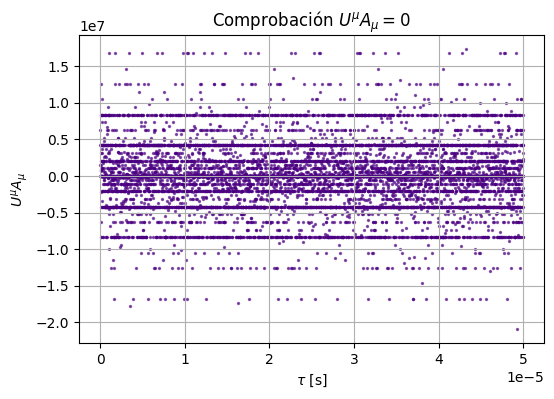

In [ ]:
# Renombrando la solución
Uo = Us[:,0]
Uvec = Us[:,1:4]
Ao = As[:,0]
Avec = As[:,1:4]

# Propiedad de la cuadrifuerza f=ma
Fo = Ao *me
Fvec = Avec *me

# Definiendo la métrica de Minkowsi (+,−,−,−)
UA = Uo*Ao - np.einsum('ij,ij->i',  Uvec, Avec)

# Imprimiendo el promedio y el valor máximo hallados
print("Máximo |U·A| =", np.max(np.abs(UA)))
print("Promedio |U·A| =", np.mean(np.abs(UA)))

# Graficando
plt.figure(figsize=(6,4))
plt.scatter(taus, UA, s=2, color='indigo', alpha=0.6)
plt.xlabel(r'$\tau$ [s]')
plt.ylabel(r'$U^\mu A_\mu$')
plt.title(r'Comprobación $U^\mu A_\mu = 0$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.grid()
plt.show()

Máximo |U·F| = 1.9852334701272664e-23
Promedio |U·F| = 2.936889327177154e-24


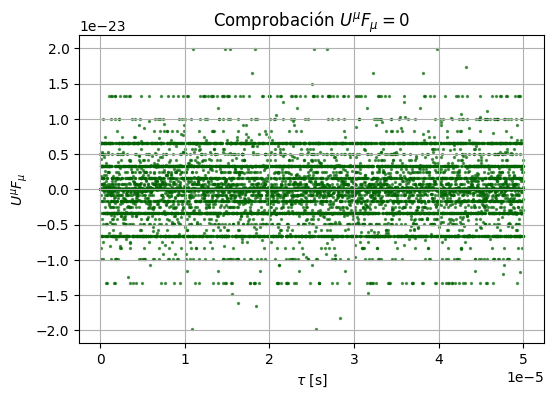

In [ ]:
# Producto interno U·F
UF = Uo*Fo - np.einsum('ij,ij->i', Uvec, Fvec)

print("Máximo |U·F| =", np.max(np.abs(UF)))
print("Promedio |U·F| =", np.mean(np.abs(UF)))

# Grafica
plt.figure(figsize=(6,4))
plt.scatter(taus, UF, s=2, color='darkgreen', alpha=0.6)
plt.xlabel(r'$\tau$ [s]')
plt.ylabel(r'$U^\mu F_\mu$')
plt.title(r'Comprobación $U^\mu F_\mu = 0$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.grid()
plt.show()

*Como es posible observar en la primera imagen, la comprobación del producto interno  ($U^\mu A_\mu$) da valores cercanos a 0 sin embargo la discrepancia de los valores es del orden de $10^7$ por ello, para verificar ortogonalidad se multiplicó el 4-vector de aceleración ($A_\mu$) por la masa del electrón $m_e$ para obtener la cuadrifuerza, por ende si se verifica ortogonalidad entre ellos ($\tilde{U} \cdot \tilde{f} = 0$) Se cumple también ortogonalidad entre U y A.*

*Como se logra apreciar en el segundo gráfico, la diferencia de los valores es del orden de $10^{-23}$ por lo cual se concluye que se cumple la ortogonalidad en ambos casos.*

## *b) Graficando el tiempo en función del tiempo propio del electrón*

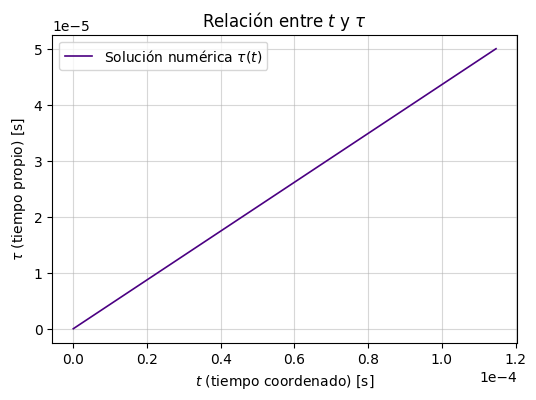

In [ ]:
# Extraemos tiempo coordenado t(tau)
ts = solucion[:, 0]

# Graficando
plt.figure(figsize=(6,4))
plt.plot(ts, taus, color='indigo', lw=1.2,
         label=r'Solución numérica $\tau(t)$')
plt.xlabel(r'$t$ (tiempo coordenado) [s]')
plt.ylabel(r'$\tau$ (tiempo propio) [s]')
plt.title(r'Relación entre $t$ y $\tau$')
plt.grid(True, alpha=0.5)
plt.legend()
plt.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
plt.show()

*Como era de esperarse, el tiempo para un observador que ve el electrón relativista transcurre más lentamente que el tiempo propio del electrón. La relación lineal entre $t$ y $\tau$ confirma que la dilatación temporal se mantiene constante en el régimen analizado.*

##*c) Gráfica del módulo de la cuadrivelocidad*

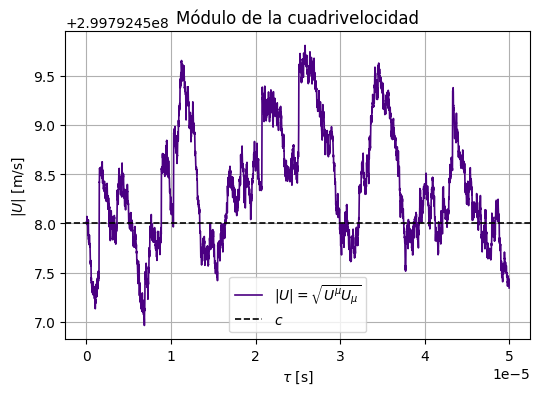

In [ ]:
# Extrayendo cada componente
Ux = Uvec[:,0]
Uy = Uvec[:,1]
Uz = Uvec[:,2]


# Módulo según la métrica de Minkowski
Umag = np.sqrt(Uo**2 - (Ux**2 + Uy**2 + Uz**2))

# Graficando
plt.figure(figsize=(6,4))
plt.plot(taus, Umag, color='indigo', lw=1.2,
         label=r'$|U| = \sqrt{U^\mu U_\mu}$')

plt.axhline(c, color='black', ls='--', lw=1.2,
             label=r'$c$')
plt.xlabel(r'$\tau$ [s]')
plt.ylabel(r'$|U|$ [m/s]')
plt.title(r'Módulo de la cuadrivelocidad')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.grid()
plt.legend()
plt.show()

*La gráfica muestra el módulo de la cuadrivelocidad $ |U| = \sqrt{U^\mu U_\mu} $ en función del tiempo propio $ \tau $. Se observa que los valores de $ |U| $ presentan pequeñas oscilaciones alrededor del valor esperado de la velocidad de la luz $ c $.*  

*Estas variaciones son del orden de $± \, 1.5\, m/s$ respecto al valor real de $ c $, lo cual representa una desviación muy pequeña en términos relativos. Dichas fluctuaciones pueden atribuirse a errores numéricos acumulados por el método de integración `odeint`, que pueden propagarse a lo largo del cálculo debido a la discretización temporal y la precisión finita de la máquina.*  


##*d) Componentes del tensor de Lorentz observadas en el sistema de referencia del electrón*

## Transformación del tensor de Faraday al sistema del electrón

*El tensor de Faraday describe los campos eléctricos y magnéticos de forma covariante.*  

*i) En el sistema del observador, donde el campo eléctrico es nulo, se escribe como:*

<br>

$$
F^{\mu\nu} =
\begin{pmatrix}
0 & 0 & 0 & 0 \\[6pt]
0 & 0 & -B_z & B_y \\[6pt]
0 & B_z & 0 & -B_x \\[6pt]
0 & -B_y & B_x & 0
\end{pmatrix}.
$$


<br>

*Cuando el electrón se mueve con una velocidad relativista $ \vec{v} $, los campos eléctricos y magnéticos se mezclan entre sí según la transformación de Lorentz, expresada en forma tensorial como:*

$$
F'^{\mu\nu} = \Lambda^{\mu}{}_{\alpha} \, F^{\alpha\beta} \, \Lambda^{\nu}{}_{\beta},
$$

*donde $ \Lambda^{\mu}{}_{\nu} $ es la matriz de transformación de Lorentz asociada a la velocidad instantánea del electrón:*

<br>

$$
\Lambda^{\mu}{}_{\nu} =
\begin{pmatrix}
\gamma & -\gamma\beta_x & -\gamma\beta_y & -\gamma\beta_z \\[6pt]
-\gamma\beta_x & 1 + (\gamma-1)\frac{\beta_x^2}{\beta^2} & (\gamma-1)\frac{\beta_x\beta_y}{\beta^2} & (\gamma-1)\frac{\beta_x\beta_z}{\beta^2} \\[6pt]
-\gamma\beta_y & (\gamma-1)\frac{\beta_y\beta_x}{\beta^2} & 1 + (\gamma-1)\frac{\beta_y^2}{\beta^2} & (\gamma-1)\frac{\beta_y\beta_z}{\beta^2} \\[6pt]
-\gamma\beta_z & (\gamma-1)\frac{\beta_z\beta_x}{\beta^2} & (\gamma-1)\frac{\beta_z\beta_y}{\beta^2} & 1 + (\gamma-1)\frac{\beta_z^2}{\beta^2}
\end{pmatrix},
$$

<br>

*donde $ \beta_i = v_i / c $ y $ \gamma = 1 / \sqrt{1 - \beta^2} $.*


<br>

*ii)En el nuevo sistema (el del electrón), los campos se extraen del tensor transformado $ F'^{\mu\nu} $ como:*

$$
E'_i = -c\, F'^{0i}, \qquad
B'_i = \frac{1}{2}\,\epsilon_{ijk}\, F'^{jk}.
$$

*De manera equivalente, las expresiones completas de la transformación relativista de los campos son:*

$$
\begin{aligned}
\vec{E}' &= \gamma \left( \vec{E} + \vec{v} \times \vec{B} \right)
 - \frac{\gamma^2}{\gamma + 1} \frac{\vec{v}}{c^2} (\vec{v} \cdot \vec{E}), \\[6pt]
\vec{B}' &= \gamma \left( \vec{B} - \frac{1}{c^2} \vec{v} \times \vec{E} \right)
 - \frac{\gamma^2}{\gamma + 1} \frac{\vec{v}}{c^2} (\vec{v} \cdot \vec{B}).
\end{aligned}
$$

*En este caso, dado que $ \vec{E} = 0 $ en el laboratorio, las ecuaciones se simplifican a:*

$$
\begin{aligned}
\vec{E}' &= \gamma \, (\vec{v} \times \vec{B}), \\[4pt]
\vec{B}' &= \gamma \, \vec{B}
 - \frac{\gamma^2}{\gamma + 1} \frac{\vec{v}}{c^2} (\vec{v} \cdot \vec{B}).
\end{aligned}
$$

*Esto muestra que incluso sin campo eléctrico en el laboratorio, el electrón en movimiento percibe un campo eléctrico en su propio marco debido a los efectos relativistas.*



*Dandole una función inicial para la matriz de Lorentz, la IA chatGPT la mejoró para evitar errores numéricos*




prompt : según la siguiente función para la transformación de Lorentz, ayudame a mejorarla ya que al aplicarla sobre el tensor electromagnético me da 0.0:


```
def matriz_lorentz(v):
    beta = v / c
    b2 = np.dot(beta, beta)
    gamma = 1.0 / np.sqrt(1.0 - b2)

    L = np.zeros((4, 4))
    L[0, 0] = gamma
    L[0, 1:] = -gamma * beta
    L[1:, 0] = -gamma * beta
    return L
```








In [ ]:
# Seleccionando el punto de la trayectoria
i = 5000
r_i = r[i]
v_i = (Uvec[i] * c) / Uo[i]  # velocidad instantánea

# Construimos la matriz de Lorentz para esa velocidad
def matriz_lorentz(v):
    beta = v / c
    b2 = np.dot(beta, beta)
    gamma = 1.0 / np.sqrt(1.0 - b2)

    L = np.zeros((4, 4))
    L[0, 0] = gamma
    L[0, 1:] = -gamma * beta
    L[1:, 0] = -gamma * beta
    if b2 > 0:
        I = np.eye(3)
        L[1:, 1:] = I + (gamma - 1) * np.outer(beta, beta) / b2
    else:
        L[1:, 1:] = np.eye(3)
    return L

In [ ]:
# Tensor de Faraday en el punto i
L = matriz_lorentz(v_i)

B = campo_B(r_i, taus[i])
E = np.zeros(3)

F = np.zeros((4, 4))

# Parte eléctrica
for j in range(3):
    F[0, j+1] = -E[j] / c
    F[j+1, 0] =  E[j] / c

# Parte magnética
F[1, 2] = -B[2]; F[2, 1] =  B[2]
F[1, 3] =  B[1]; F[3, 1] = -B[1]
F[2, 3] = -B[0]; F[3, 2] =  B[0]

# Transformación al sistema del electrón
Fp = L @ F @ L.T

# Tensores en fomra matricial
print("\nTensor de Faraday en el sistema del observador (F^{μν}):")
print(F)

print("\nTensor de Faraday en el sistema del electrón (F'^{μν}):")
print(Fp)



Tensor de Faraday en el sistema del observador (F^{μν}):
[[ 0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -4.00000000e-04 -3.65067266e-06]
 [ 0.00000000e+00  4.00000000e-04  0.00000000e+00 -1.15343314e-05]
 [ 0.00000000e+00  3.65067266e-06  1.15343314e-05  0.00000000e+00]]

Tensor de Faraday en el sistema del electrón (F'^{μν}):
[[ 4.68621491e-22  2.27941459e-05  2.41824725e-05 -4.36582357e-07]
 [-2.27941459e-05  7.68515804e-24 -4.01404252e-04  1.06185975e-05]
 [-2.41824725e-05  4.01404252e-04 -8.69393569e-23  3.57714337e-06]
 [ 4.36582357e-07 -1.06185975e-05 -3.57714337e-06  8.41702041e-23]]


*El resultado obtenido demuestra que, al aplicar la transformación de Lorentz al tensor de Faraday, un electrón que se mueve a velocidades relativistas percibe un campo eléctrico distinto de cero en su propio marco de referencia, aunque para el observador externo solo exista un campo magnético.*

*Esto refleja, de manera más sencilla, cómo la relatividad muestra que los campos eléctrico y magnético son manifestaciones del mismo fenómeno, dependiendo del sistema de referencia desde el cual se observen y de la velocidad de ese sistema.*


# Punto 3

##*Radiación sincrotrón y frecuencia de giro del electrón*


*A lo largo de la trayectoria se debe calcular el campo magnético total como:*

<br>

$$
|\vec{B}(t)| = \sqrt{B_x^2(t) + B_y^2(t) + B_z^2(t)}
$$

*Este valor se obtiene evaluando la función `campo_B` en cada punto $(x(t), y(t), z(t))$ de la trayectoria.*

<br>

*La frecuencia ciclotrón relativista para un electrón en un campo magnético es:*

$$
f_g(t) = \frac{|q_e|\,|\vec{B}(t)|}{2\pi\,\gamma(t)\,m_e}
$$


*A partir de las posiciones en el plano perpendicular al campo $(x(t), y(t))$, se construye una señal compleja de la forma:*

<br>

$$
s(t) = x(t) + i\,y(t)
$$

<br>

*Además la Transformada Rápida de Fourier (FFT) de esta señal permite identificar la frecuencia dominante en la trayectoria del electrón:*

$$
f_{\text{obs}} = \text{frecuencia donde } P(f) \text{ es máxima}
$$



In [ ]:
# Calcular la magnitud de B a lo largo de la trayectoria
B_tray = np.array([campo_B(np.array([x[i], y[i], z[i]]),
                           ts[i]) for i in range(len(ts))])

# Valor del campo magnético
B_abs = np.linalg.norm(B_tray, axis=1)

gamma_t = Uo / c

# Frecuencia teórica instantánea
f_teo_t = (np.abs(qe) * B_abs) / (2.0 * np.pi * gamma_t * me)

# Frecuencia observada por FFT de la señal compleja en el plano xy
t_uniform = np.linspace(ts[0], ts[-1], len(ts))
x_s = interp1d(ts, x, kind='cubic')
y_s = interp1d(ts, y, kind='cubic')
x_u = x_s(t_uniform)
y_u = y_s(t_uniform)
s_complex = x_u + 1j*y_u
dt = t_uniform[1] - t_uniform[0]
fs = 1.0 / dt

# Periodogram del radio
fvals, Pxx = periodogram(np.abs(s_complex), fs=fs)
idx_peak = np.argmax(Pxx[1:]) + 1
f_peak_fft = fvals[idx_peak]

# Usando la media de la frecuencia teórica
mask = (ts >= ts[0]) & (ts <= ts[-1])   # intervalo temporal
f_teo_mean = np.mean(f_teo_t[mask])

print("\nFreq a partir de la FFT  : {:.3e} Hz".format(f_peak_fft))
print("\nFreq teórica = {:.3e} Hz".format(f_teo_mean))
print('\nLa razón entre las frecuencias: {:.3f}'.format(f_peak_fft/f_teo_mean))



Freq a partir de la FFT  : 4.507e+06 Hz

Freq teórica = 4.883e+06 Hz

La razón entre las frecuencias: 0.923


*Para hacer una compración gráfica se utilizó la IA Gemini.*


prompt: podrías realizar la gráfia de comparación que te voy a brindar un poco más estética.

```
# Grafica de las frecuencias
plt.semilogy(fvals, Pxx)
plt.axvline(f_peak_fft, color='r', ls='--',
            label=f'peak FFT={f_peak_fft:.2e} ')

plt.axvline(f_teo_mean, color='g', ls='--',
            label=f'f teorica media={f_teo_mean:.2e} Hz')
plt.xlim(0, 5*f_peak_fft)
plt.xlabel('Frecuencia ')
plt.ylabel('PSD')
plt.legend()
plt.tight_layout()
plt.show()
```



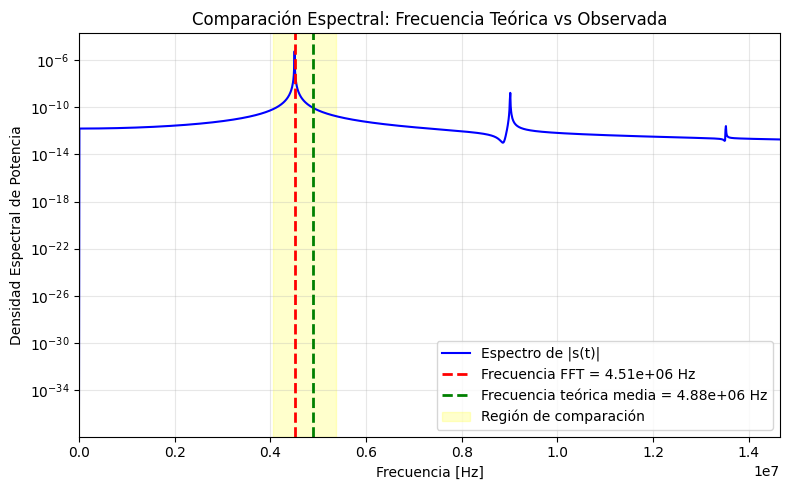

In [ ]:
# Graficando las frecuencias
plt.figure(figsize=(8, 5))
plt.semilogy(fvals, Pxx, 'b-', label='Espectro de |s(t)|')
plt.axvline(f_peak_fft, color='r', ls='--', linewidth=2,
           label=f'Frecuencia FFT = {f_peak_fft:.2e} Hz')
plt.axvline(f_teo_mean, color='g', ls='--', linewidth=2,
           label=f'Frecuencia teórica media = {f_teo_mean:.2e} Hz')

# Resaltar la región alrededor de las frecuencias de interés
f_min = min(f_peak_fft, f_teo_mean)
f_max = max(f_peak_fft, f_teo_mean)
plt.axvspan(f_min*0.9, f_max*1.1, alpha=0.2, color='yellow',
           label='Región de comparación')

plt.xlim(0, 3*f_max)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad Espectral de Potencia')
plt.title('Comparación Espectral: Frecuencia Teórica vs Observada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Ahora hallando la frecuencia en la radiación sincrotrón, usando la ecuación proporcionada en el enunciado*

In [ ]:
# v desde la cuadrivelocidad
v_vec = (Uvec * c) / Uo[:, None]   # v = c * U^i / U^0

# magnitud y gamma
v = np.linalg.norm(v_vec, axis=1)
gamma = 1.0 / np.sqrt(1.0 - (v / c)**2)

# Calcular componente perpendicular del campo magnetico
B_perp = np.linalg.norm(np.cross(B_tray, v_vec), axis=1) / (v + 1e-20)

# Frecuencias sincrotrón
f_crit = (3 / (4 * np.pi)) * gamma**2 * (np.abs(qe) * B_perp) / me
f_peak = 0.29 * f_crit

delta_f_rel = (np.max(f_peak) - np.min(f_peak)) / np.mean(f_peak)

# Promedios
print(f"\nFrecuencia crítica media : {np.mean(f_crit):.3e} Hz")
print(f"\nFrecuencia pico media : {np.mean(f_peak):.3e} Hz")
print(f"\nVariación relativa de f_peak = {delta_f_rel:.3%}")


Frecuencia crítica media : 3.290e+06 Hz

Frecuencia pico media : 9.542e+05 Hz

Variación relativa de f_peak = 16.616%


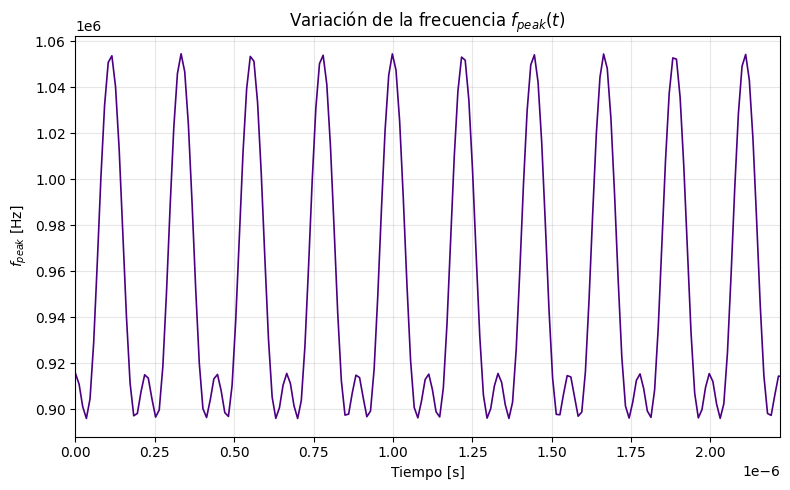

In [ ]:
# Graficando la variación de la frecuencia máxima

T = 1 / f_peak_fft  # periodo aproximado
t0 = ts[0]
plt.figure(figsize=(8,5))
plt.plot(ts, f_peak, color='indigo',
         lw=1.2, label=r'$f_{\mathrm{peak}}(t)$')

# Zoom para ver solo 10 períodos
plt.xlim(t0, t0 + 10*T)

plt.xlabel('Tiempo [s]')
plt.ylabel('$f_{peak}$ [Hz]')
plt.title('Variación de la frecuencia $f_{peak}(t)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


*A partir de la trayectoria relativista del electrón y del cálculo del campo magnético total, se obtuvieron las frecuencias teórica y observada mediante la Transformada Rápida de Fourier (FFT). Ambas presentan una buena concordancia, con una pequeña diferencia posiblemente atribuida al método numérico y a la resolución temporal utilizada en la integración.*

*Las frecuencias obtenidas de la radiación sincrotrón muestran una frecuencia crítica media de $ 3.29\times10^6\ \text{Hz} $ y una frecuencia pico media de $ 9.54\times10^5\ \text{Hz} $.  
Estos valores corresponden a la aproximación derivada de la trayectoria calculada del electrón, indicando que la emisión se concentra principalmente en el rango de megahercios (MHz).*


# Punto 4

##*Beaming relativista en el jet*

*En el sistema de referencia del electrón la emisión puede considerarse isotrópica, pero debido al beaming relativista, la radiación se concentra en un cono de apertura:*

$$
\theta_{\text{beam}} \approx \frac{1}{\gamma}
$$

El observador percibe la emisión amplificada por el factor Doppler:

$$
\delta = \frac{1}{\gamma (1 - \beta \cos\theta)}
$$

y la potencia observada se transforma como:

$$
P_{\text{obs}} = P_{\text{em}} \, \delta^4
$$

con una potencia de radiación sincrotrón dada por:

$$
P_{\text{em}} = \frac{2}{3} \frac{q^4}{m^2 c^3} \, \gamma^2 \, B_\perp^2
$$

*En este ejercicio se estudia cómo cambia la curva de luz observada $ I(t) $ al variar el ángulo del observador $ \theta_{\text{obs}} $ respecto al eje del jet.*

**Referencia: Rybicki & Lightman (1979), "Radiative Processes in Astrophysics"**


In [ ]:
# Parámetros del observador
R_obs = 1e14  # metros

# Potencia de radiación sincrotrón
def potencia_sincrotron(gamma, B_perp, q=qe, m=me, c=c):
    P = (2/3) * (q**4)/(m**2 * c**3) * gamma**2 * B_perp**2
    return P


# Estudiar variación con ángulo del observador
angulos = [1, 10, 30, 50, 70, 89]
colores = [ 'purple', 'orange', 'blue', 'red' , 'green', "indigo"]


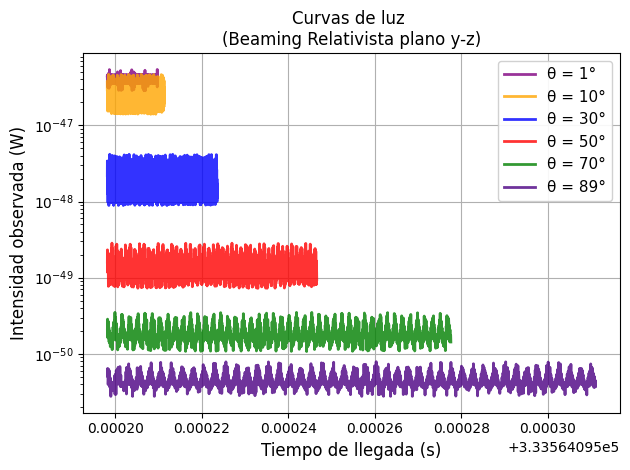

In [ ]:
for idx, angulo_grados in enumerate(angulos):
    theta_obs = np.deg2rad(angulo_grados)
    r_obs = np.array([0.0,
                       R_obs*np.sin(theta_obs),
                       R_obs*np.cos(theta_obs)])

    # Inicializar arrays para estos ángulos
    P_obs_test = np.zeros(len(ts))
    t_llegada = np.zeros(len(ts))

    for i in range(len(ts)):
        ri = r[i]
        vi = (Uvec[i] * c) / Uo[i]
        vmag = np.linalg.norm(vi)
        beta = vmag / c
        gamma_val = Uo[i] / c

        # Vector del electrón al observador
        R_vec = r_obs - ri
        R_dist = np.linalg.norm(R_vec)
        n_hat_obs = R_vec / R_dist

        # Ángulo entre velocidad y línea de visión
        if vmag > 1e-10:
            cos_theta = np.dot(vi, n_hat_obs) / vmag
            cos_theta = np.clip(cos_theta, -1.0, 1.0)
        else:
            cos_theta = 0.0

        # Factor Doppler relativista
        factor_doppler = 1.0 / (gamma_val * (1.0 - beta * cos_theta))

        # Potencia de radiación sincrotrón
        B_current = campo_B(ri, ts[i])
        v_hat = vi / (vmag + 1e-20)
        B_perp = np.linalg.norm(B_current - np.dot(B_current, v_hat) * v_hat)
        P_emision = potencia_sincrotron(gamma_val, B_perp)

        # Tiempo de llegada y potencia observada
        t_llegada[i] = ts[i] + R_dist / c
        P_obs_test[i] = P_emision * factor_doppler**4

    # Construir la curva para cada uno de los ángulos
    t_min, t_max = np.min(t_llegada), np.max(t_llegada)
    n_bins = min(2000, len(ts))
    t_grid = np.linspace(t_min, t_max, n_bins)
    I_test, bin_edges = np.histogram(t_llegada,
                                     bins=t_grid, weights=P_obs_test)
    t_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Graficar cada curva de luz
    plt.plot(t_centers, I_test, lw=2.0, color=colores[idx],
             label=f'θ = {angulo_grados}°', alpha=0.8)

# Graficando las curvas de luz
plt.xlabel('Tiempo de llegada (s)', fontsize=12)
plt.ylabel('Intensidad observada (W)', fontsize=12)
plt.title('Curvas de luz \n(Beaming Relativista plano y-z)')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid()
plt.yscale('log')
plt.tight_layout()
plt.show()

*Las curvas de luz muestran una variabilidad rápida y oscilaciones regulares, características de la radiación sincrotrón. Estas oscilaciones reflejan los pulsos periódicos de radiación detectados cuando el electrón describe un movimiento helicoidal dentro del campo magnético del jet.*

*El evento modelado tiene diferentes intervalos de tiempo para el observador. Como se puede analizar, estos intervalos aumentan cuando crece el ángulo $\theta$, mientras que la intensidad disminuye. Esto quiere decir que la radiación observada se ve afectada por los efectos relativistas de proyección y Doppler, de modo que a mayores ángulos de visión el movimiento del electrón se percibe más lento y menos brillante. En cambio, para ángulos pequeños, el tiempo aparente del evento se acorta y la intensidad aumenta notablemente, reproduciendo el comportamiento esperado de un jet relativista dirigido hacia el observador.*

## Declaración de uso IAs.

*Declaro que la mayor parte del código contenido en este notebook es de mi propia autoría y no ha sido obtenido usando exclusivamente grandes modelos de lenguaje (LLMs o IAs)*.

*En casos excepcionales*:

- *Las celdas con gráficos complejos en `plotly` han sido elaboradas con el apoyo del modelo Gemini que viene incorporado en `Google Colab`*.
- *Cualquier uso adicional fue declarado en las celdas respectivas y en caso de que grandes porciones de código hayan sido extraídas de una IA, lo he indicado explícitamente agregando entre los comentarios el o los _prompts_ utilizados.*